## Purpose
This notebook is to calculate stocks with a 14-day RSI of 25 and identify the first 25 highest RSI stocks.
This stock is considered oversold, meaning it could be undervalued and could bounce back.

In [43]:
%matplotlib inline
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, current_date, date_sub
import configparser
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.sql import DataFrame
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import DoubleType
from config_loader import load_config

In [44]:
tablename = 'stocksinfp'
# Load configuration details
try:
    url, driver, username, password = load_config()
    print(f"URL: {url}, Driver: {driver}, Username: {username}, Table: {tablename}")
except Exception as e:
    print(f"Error loading config: {e}")

URL: jdbc:mysql://localhost/stocksdb, Driver: com.mysql.cj.jdbc.Driver, Username: quizadmin, Table: stocksinfp


In [45]:
spark = SparkSession.builder.appName("Best25Stocks") \
.master("local[*]") \
.config("spark.jars",
                "/Users/gaurav/.m2/repository/com/mysql/mysql-connector-j/8.0.33/mysql-connector-j-8.0.33.jar") \
.getOrCreate()

In [46]:
stock_df = spark.read.format("jdbc").options(url=url, driver=driver, user=username, password=password, dbtable=tablename).load()
#spark.sparkContext.stop()

In [47]:
# Filter for records in the last 1 year
one_year_ago = date_sub(current_date(), 180)
filtered_df = stock_df.filter(col("Date") >= one_year_ago)
#filtered_df = filtered_df.filter(col("Symbol") == 'GOOG')
# Show the result
filtered_df.printSchema()
filtered_df.show(2, truncate=False)

root
 |-- Date: date (nullable = true)
 |-- Open: string (nullable = true)
 |-- High: string (nullable = true)
 |-- Low: string (nullable = true)
 |-- Close: string (nullable = true)
 |-- Adj Close: string (nullable = true)
 |-- Volume: string (nullable = true)
 |-- symbol: string (nullable = true)
 |-- price_change: double (nullable = true)

+----------+-----------------+-----------------+------------------+------------------+------------------+--------+------+----------------+
|Date      |Open             |High             |Low               |Close             |Adj Close         |Volume  |symbol|price_change    |
+----------+-----------------+-----------------+------------------+------------------+------------------+--------+------+----------------+
|2024-12-17|250.0800018310547|253.8300018310547|249.77999877929688|253.47999572753906|253.47999572753906|51356400|AAPL  |2.44000244140625|
|2024-12-17|170.5800018310547|176.5            |170.2100067138672 |175.3800048828125 |173.741592407

In [48]:
# Function to calculate the 14-day RSI
def calculate_rsi(df, window_size=14):
    # Calculate price change
    #df = df.withColumn('price_change', F.col('Close') - F.lag('Close', 1).over(Window.partitionBy('symbol').orderBy('Date')))
    
    # Step 1: Create a window partitioned by symbol and ordered by date (descending to keep last 14)
    latest_14_days_window = Window.partitionBy("symbol").orderBy(F.desc("Date"))
    
    # Step 2: Rank rows based on the latest date and filter only last 14 per stock
    df = df.withColumn("rank", F.row_number().over(latest_14_days_window))
    df = df.filter(F.col("rank") <= 14).drop("rank")  # Keep only last 14 rows per symbol
    
    
    # Calculate gain and loss
    df = df.withColumn('gain', F.when(F.col('price_change') > 0, F.col('price_change')).otherwise(0))
    df = df.withColumn('loss', F.when(F.col('price_change') < 0, -F.col('price_change')).otherwise(0))

    # Calculate rolling average gain and loss
    window_spec = Window.partitionBy('symbol').orderBy('Date').rowsBetween(-window_size + 1, 0)
    
    df = df.withColumn('avg_gain', F.avg('gain').over(window_spec))
    df = df.withColumn('avg_loss', F.avg('loss').over(window_spec))

    # Calculate RS (Relative Strength) and RSI
    df = df.withColumn('rs', F.col('avg_gain') / F.col('avg_loss'))
    df = df.withColumn('rsi', 100 - (100 / (1 + F.col('rs'))))
    # Remove rows where RSI is null
    df = df.filter(F.col("rsi").isNotNull()) #& (F.col("rsi") != 0 )

    return df

In [49]:
# Apply RSI calculation
df_rsi = calculate_rsi(filtered_df)

In [50]:
# Show the result
#df_rsi.select('symbol', 'Date', 'rs','avg_gain','avg_loss','rsi').show(15)

In [51]:
# Step 8: Select only the latest RSI value per stock
latest_rsi_df = df_rsi.withColumn(
    "rank", F.row_number().over(Window.partitionBy("symbol").orderBy(F.desc("Date")))
).filter(F.col("rank") == 1).drop("rank")

# Filter the stocks with RSI <= 25
low_rsi_stocks = latest_rsi_df.filter(latest_rsi_df['rsi'] <= 25)

# Sort the stocks by RSI value in ascending order
low_rsi_sorted = low_rsi_stocks.orderBy('rsi', ascending=True)

# Select the top 25 stocks with the lowest RSI
top_25_low_rsi_stocks = low_rsi_sorted.limit(25)

# Convert Spark DataFrame to Pandas DataFrame for plotting
top_25_low_rsi_pandas = top_25_low_rsi_stocks.toPandas()

#top_25_low_rsi_pandas

In [52]:
# Step 1: Get the latest price for each stock
latest_price_df = filtered_df.withColumn(
    "rank", F.row_number().over(Window.partitionBy("symbol").orderBy(F.desc("Date")))
).filter(F.col("rank") == 1).select("symbol", "Close").withColumnRenamed("Close", "latest_price")

# Step 2: Get the price 14 days ago for each stock
price_14_days_ago_df = filtered_df.withColumn(
    "rank", F.row_number().over(Window.partitionBy("symbol").orderBy(F.desc("Date")))
).filter(F.col("rank") == 14).select("symbol", "Close").withColumnRenamed("Close", "price_14_days_ago")

# Step 3: Join both datasets
price_drop_df = latest_price_df.join(price_14_days_ago_df, on="symbol", how="inner")

# Step 4: Calculate the percentage drop
price_drop_df = price_drop_df.withColumn(
    "drop_percent", ((F.col("price_14_days_ago") - F.col("latest_price")) / F.col("price_14_days_ago")) * 100
)
price_drop_df.show()

+------+------------------+------------------+-------------------+
|symbol|      latest_price| price_14_days_ago|       drop_percent|
+------+------------------+------------------+-------------------+
|  AAPL| 196.4499969482422| 200.2100067138672| 1.8780328852386827|
|  ABBV| 191.0800018310547|185.72000122070312|-2.8860653538236445|
|   ACB| 5.849999904632568|  5.46999979019165| -6.946985905233537|
|  ACHR| 9.989999771118164|10.920000076293945|  8.516486251632031|
|   ADI|225.02999877929688|  215.906982421875| -4.225438313799323|
|  AFRM| 59.11000061035156| 51.18000030517578|-15.494334228000831|
|    AI|23.760000228881836|23.920000076293945| 0.6688956810275186|
|   ALB|60.720001220703125| 58.40892028808594|-3.9567259953075937|
|  ALEC|1.5399999618530273|1.2599999904632568|-22.222220119765602|
|  ALGM|28.649999618530273|  26.1200008392334| -9.686059333875306|
|  ALGT| 51.04999923706055| 55.88999938964844|  8.659867964651154|
|  ALLT| 8.140000343322754| 8.210000038146973| 0.8526150365282

In [53]:
# Step 5: Filter for the 25 stocks with the lowest RSI
top_25_low_rsi_stocks_v2 = top_25_low_rsi_stocks.select("symbol").join(price_drop_df, on="symbol", how="inner")

top_25_low_rsi_stocks_v2.show(25)

+------+--------------------+-------------------+------------------+
|symbol|        latest_price|  price_14_days_ago|      drop_percent|
+------+--------------------+-------------------+------------------+
|  AMBA|   50.72999954223633|  62.47999954223633|18.806018063519716|
|  CLOV|   2.884999990463257| 3.2100000381469727| 10.12461195705554|
|  FRPT|    74.2699966430664|   83.0199966430664|10.539629431231463|
|   GME|  22.139999389648438|   35.0099983215332|36.760924161395806|
|    IT|   404.9700012207031|  444.8599853515625|  8.96686270834974|
|  KINS|   14.84000015258789| 16.559999465942383| 10.38646961850377|
|  NOVA|0.002099999925121665|0.19670000672340393| 98.93238441619646|
|  OKTA|    97.4800033569336|              125.5| 22.32669055224415|
|   PDD|  100.58000183105469|  102.9800033569336|  2.33055102703812|
|   PVH|   62.70000076293945|  86.49015808105469|27.506201683456478|
|   SKY|   61.41999816894531|  70.44999694824219| 12.81759995806811|
+------+--------------------+-----

In [54]:
# Step 6: Convert to Pandas for visualization
top_25_low_rsi_pandas_v2 = top_25_low_rsi_stocks_v2.toPandas()
# Convert price columns to numeric
top_25_low_rsi_pandas_v2["latest_price"] = pd.to_numeric(top_25_low_rsi_pandas_v2["latest_price"])
top_25_low_rsi_pandas_v2["price_14_days_ago"] = pd.to_numeric(top_25_low_rsi_pandas_v2["price_14_days_ago"])

top_25_low_rsi_pandas_v2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symbol             11 non-null     object 
 1   latest_price       11 non-null     float64
 2   price_14_days_ago  11 non-null     float64
 3   drop_percent       11 non-null     float64
dtypes: float64(3), object(1)
memory usage: 480.0+ bytes


In [55]:


# Step 6: Melt the dataframe for Seaborn catplot
# Melt DataFrame for Seaborn
df_melted = top_25_low_rsi_pandas_v2.melt(id_vars=["symbol", "drop_percent"], 
                                       value_vars=["price_14_days_ago","latest_price"], 
                                       var_name="Price Type", 
                                       value_name="Price")
df_melted

,symbol,drop_percent,Price Type,Price
0,AMBA,18.806018,price_14_days_ago,62.480000
1,CLOV,10.124612,price_14_days_ago,3.210000
2,FRPT,10.539629,price_14_days_ago,83.019997
3,GME,36.760924,price_14_days_ago,35.009998
4,IT,8.966863,price_14_days_ago,444.859985
5,KINS,10.386470,price_14_days_ago,16.559999
6,NOVA,98.932384,price_14_days_ago,0.196700
7,OKTA,22.326691,price_14_days_ago,125.500000
8,PDD,2.330551,price_14_days_ago,102.980003
9,PVH,27.506202,price_14_days_ago,86.490158


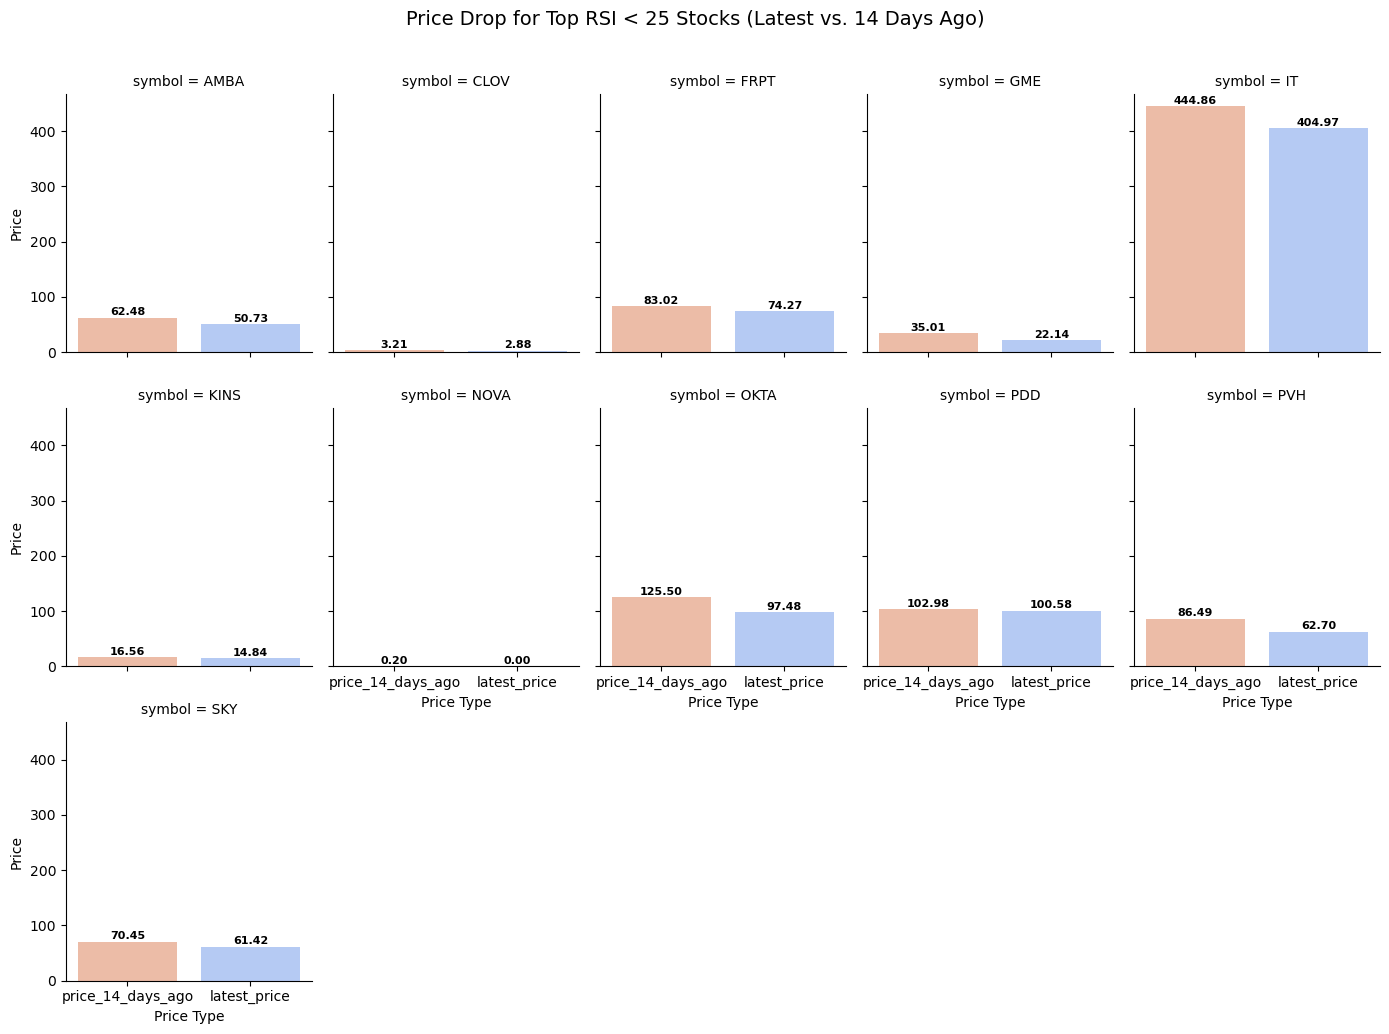

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assign color based on drop percent
df_melted["color"] = df_melted.apply(lambda row: "red" if row["drop_percent"] < 0 else "green", axis=1)

# Plot using catplot
g = sns.catplot(x="Price Type", y="Price", col="symbol", col_wrap=5, 
                data=df_melted, kind="bar", height=3.5, aspect=0.8, 
                hue="Price Type", palette="coolwarm_r", legend=False)

# Display actual values on top of bars
for ax in g.axes.flat:
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width() / 2, height + 0.5, 
                f'{height:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Set title
g.fig.suptitle('Price Drop for Top RSI < 25 Stocks (Latest vs. 14 Days Ago)', fontsize=14)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.9)

# Show plot
plt.show()


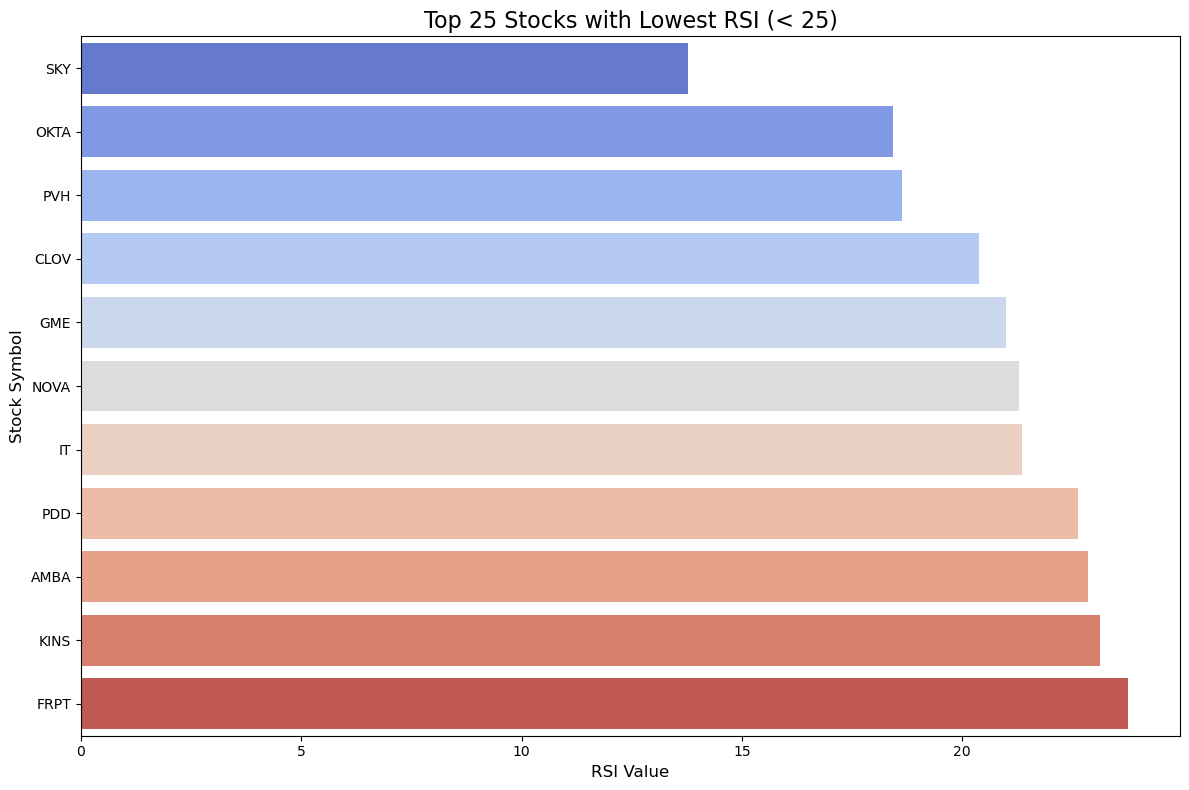

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Create the bar plot for the stocks with low RSI (<= 25)
plt.figure(figsize=(12, 8))
sns.barplot(x='rsi', y='symbol', data=top_25_low_rsi_pandas, hue='symbol', palette='coolwarm', legend=False)

# Add labels and title
plt.title('Top 25 Stocks with Lowest RSI (< 25)', fontsize=16)
plt.xlabel('RSI Value', fontsize=12)
plt.ylabel('Stock Symbol', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()